# SNR and Summary Plots
This notebook loads the generated Asym_* data and produces phase-resolved SNR plots plus summary trend plots for RMS and effect size.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [2]:
regions = [
    (0.80, 1),   # Rayleigh + optical continuum / H− slope
    (1, 1.16),   # continuum (reference baseline)
    (1.16, 1.30),   # weak H2O + continuum transition
    (1.30, 1.50),   # STRONG H2O band (main signal)
    (1.50, 1.70),   # H2O wing / opacity plateau
    (1.70, 1.95),   # second H2O band
    (1.95, 2.20)    # deep IR tail (temperature + opacity)
]
work_dir = os.getcwd()
def load_phase_data(folder):
    base = os.path.join(work_dir, folder)
    def load_one(phase):
        path = os.path.join(base, f"{phase}.txt")
        data = np.loadtxt(path)
        data = data[~np.isnan(data).any(axis=1)]
        return data
    return (load_one("ingress"), load_one("mid"), load_one("egress"))
def load_global_metrics(folders):
    results = []
    for folder in folders:
        ing, mid, egr = load_phase_data(folder)
        λ = ing[:, 0]
        transit_ing = ing[:, -1]
        transit_mid = mid[:, -1]
        transit_egr = egr[:, -1]
        ni = ing[:, 2]
        ne = egr[:, 2]
        global_rms = np.sqrt(np.mean((transit_ing - transit_egr)**2))
        μ_i = np.mean(transit_ing)
        μ_e = np.mean(transit_egr)
        σ_i = np.std(transit_ing)
        σ_e = np.std(transit_egr)
        E = (μ_i - μ_e) / np.sqrt((σ_i**2 + σ_e**2) / 2) if (σ_i**2 + σ_e**2) > 0 else np.nan
        results.append({'Asymmetry': folder, 'RMS': global_rms, 'E': E})
    return pd.DataFrame(results)

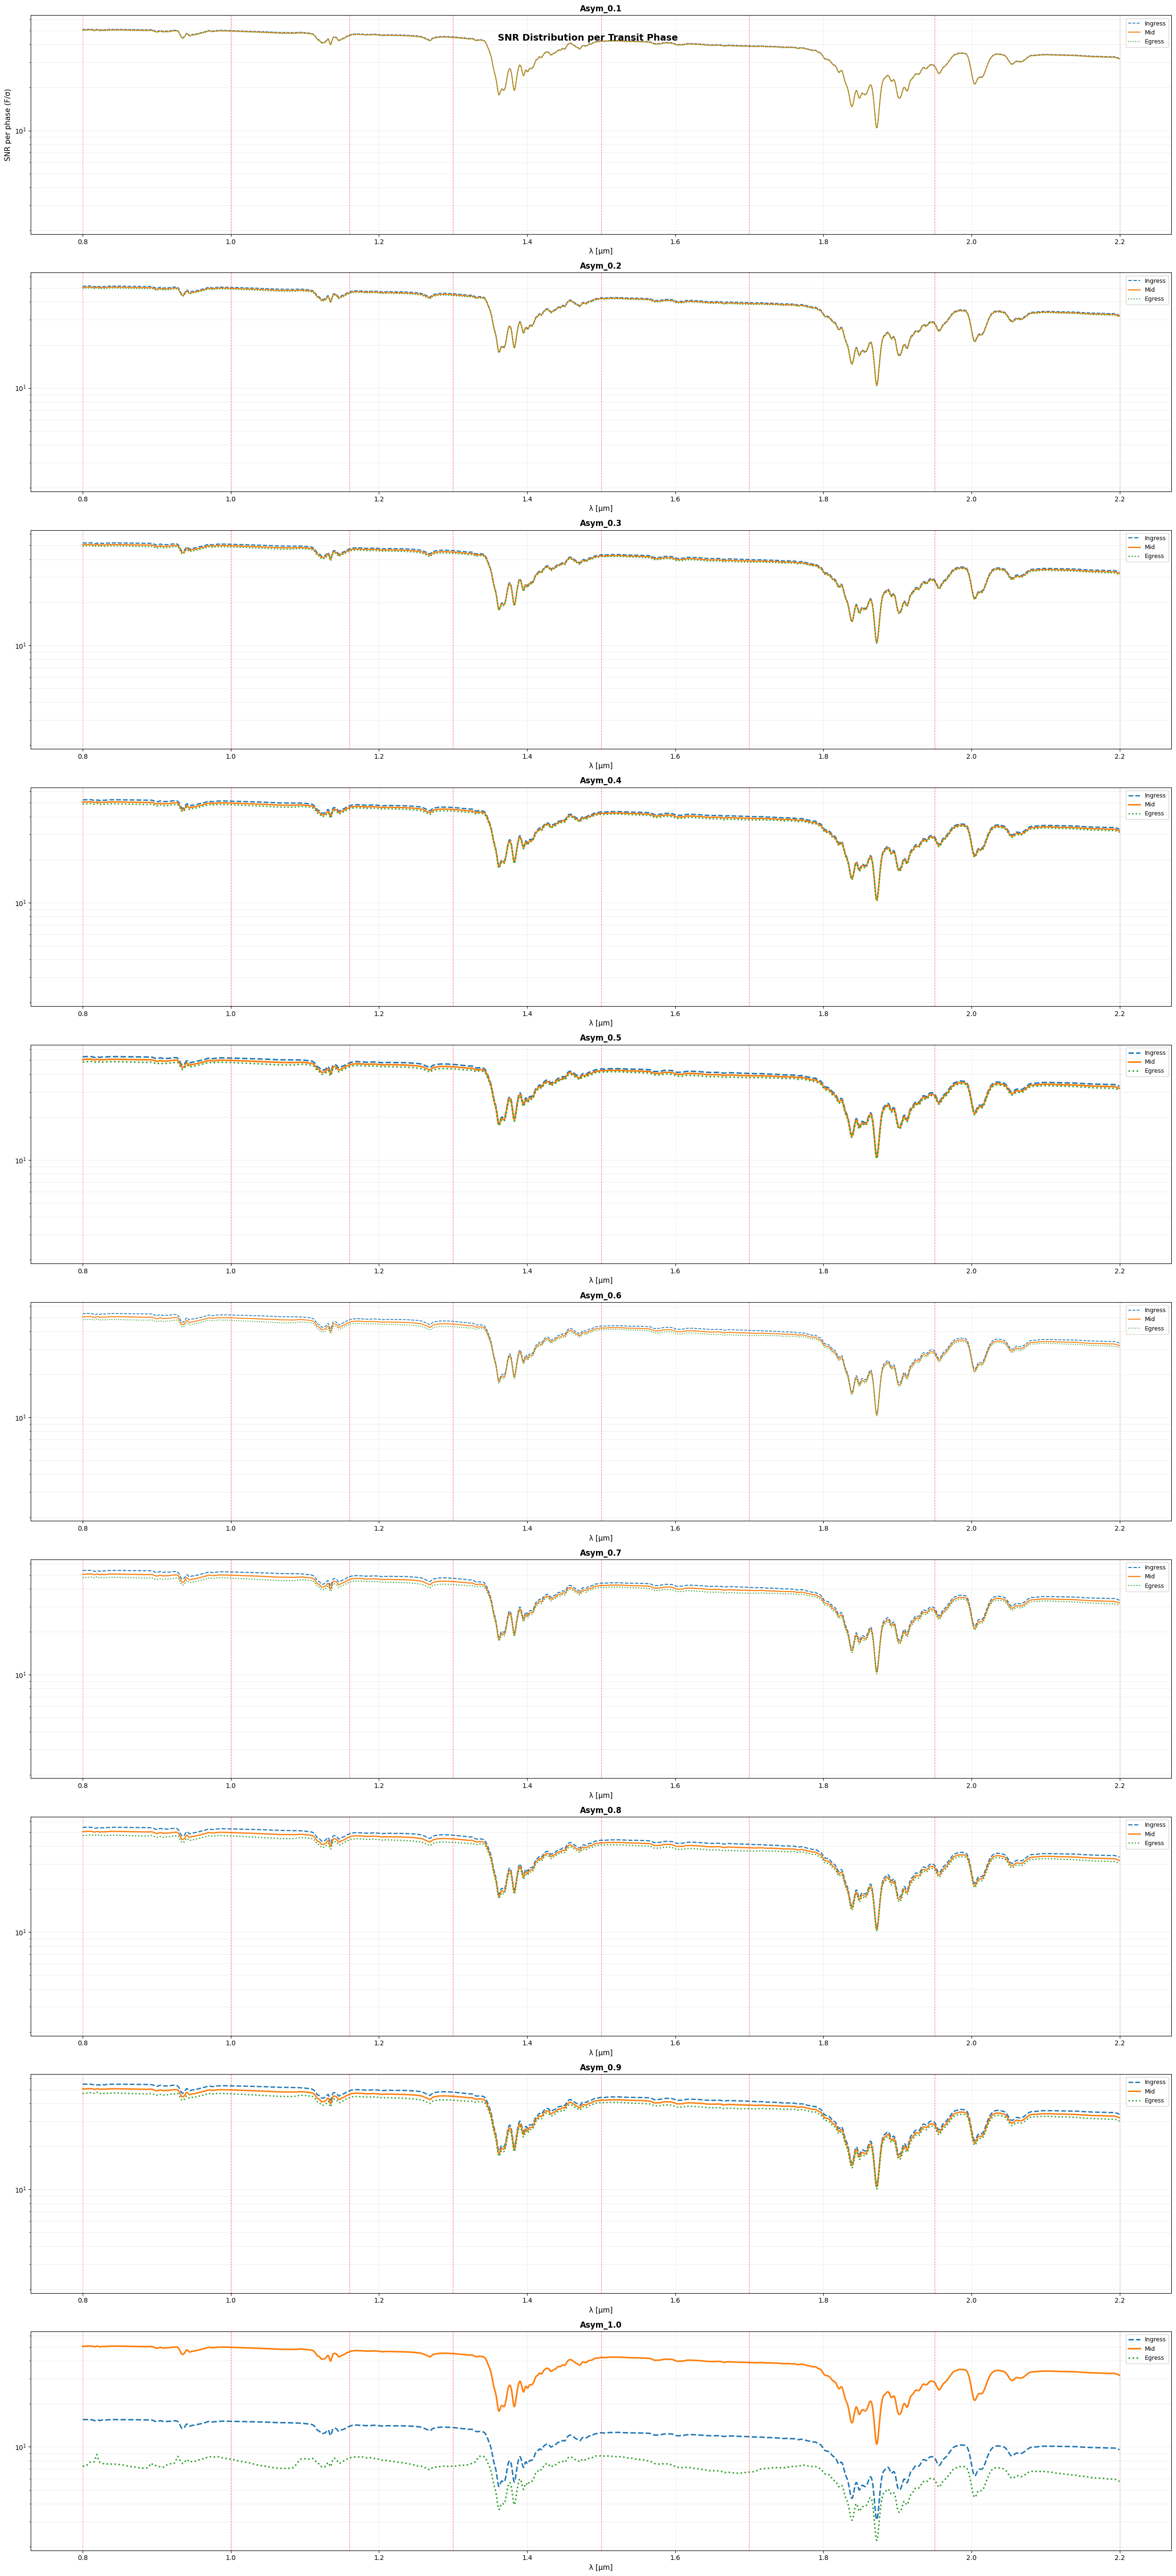

In [11]:
asymmetry_levels = np.arange(0.1, 1.01, 0.1)
folders = [f"Asym_{a:.1f}" for a in asymmetry_levels]
fig, axes = plt.subplots(10, 1, figsize=(25, 55), sharey=True)
for i, folder in enumerate(folders):
    ax = axes[i]
    ing, mid, egr = load_phase_data(folder)
    λ = ing[:, 0]
    fi = ing[:, -1]
    fm = mid[:, -1]
    fe = egr[:, -1]
    ni = ing[:, 2]
    nm = mid[:, 2]
    ne = egr[:, 2]
    snr_ing = np.divide(fi, ni, out=np.zeros_like(fi), where=ni > 0)
    snr_mid = np.divide(fm, nm, out=np.zeros_like(fm), where=nm > 0)
    snr_egr = np.divide(fe, ne, out=np.zeros_like(fe), where=ne > 0)
    lw = 1.2 + (i % 5) * 0.25
    ax.plot(λ, snr_ing, linestyle='--', label="Ingress", linewidth=lw)
    ax.plot(λ, snr_mid, linestyle='-', label="Mid", linewidth=lw + 0.2)
    ax.plot(λ, snr_egr, linestyle=':', label="Egress", linewidth=lw + 0.1)
    for r1, r2 in regions:
        ax.axvline(r1, linestyle='--', color='red', alpha=0.3, linewidth=0.8)
        ax.axvline(r2, linestyle='--', color='red', alpha=0.3, linewidth=0.8)
    ax.set_yscale('log')
    ax.set_title(folder, fontsize=12, fontweight='bold')
    ax.set_xlabel("λ [μm]", fontsize=11)
    ax.grid(True, alpha=0.2, which='both')
    ax.legend(fontsize=9)
axes[0].set_ylabel("SNR per phase (F/σ)", fontsize=11)
plt.suptitle("SNR Distribution per Transit Phase", fontsize=14, fontweight='bold')
plt.subplots_adjust(top=0.94)
plt.tight_layout()
plt.show()

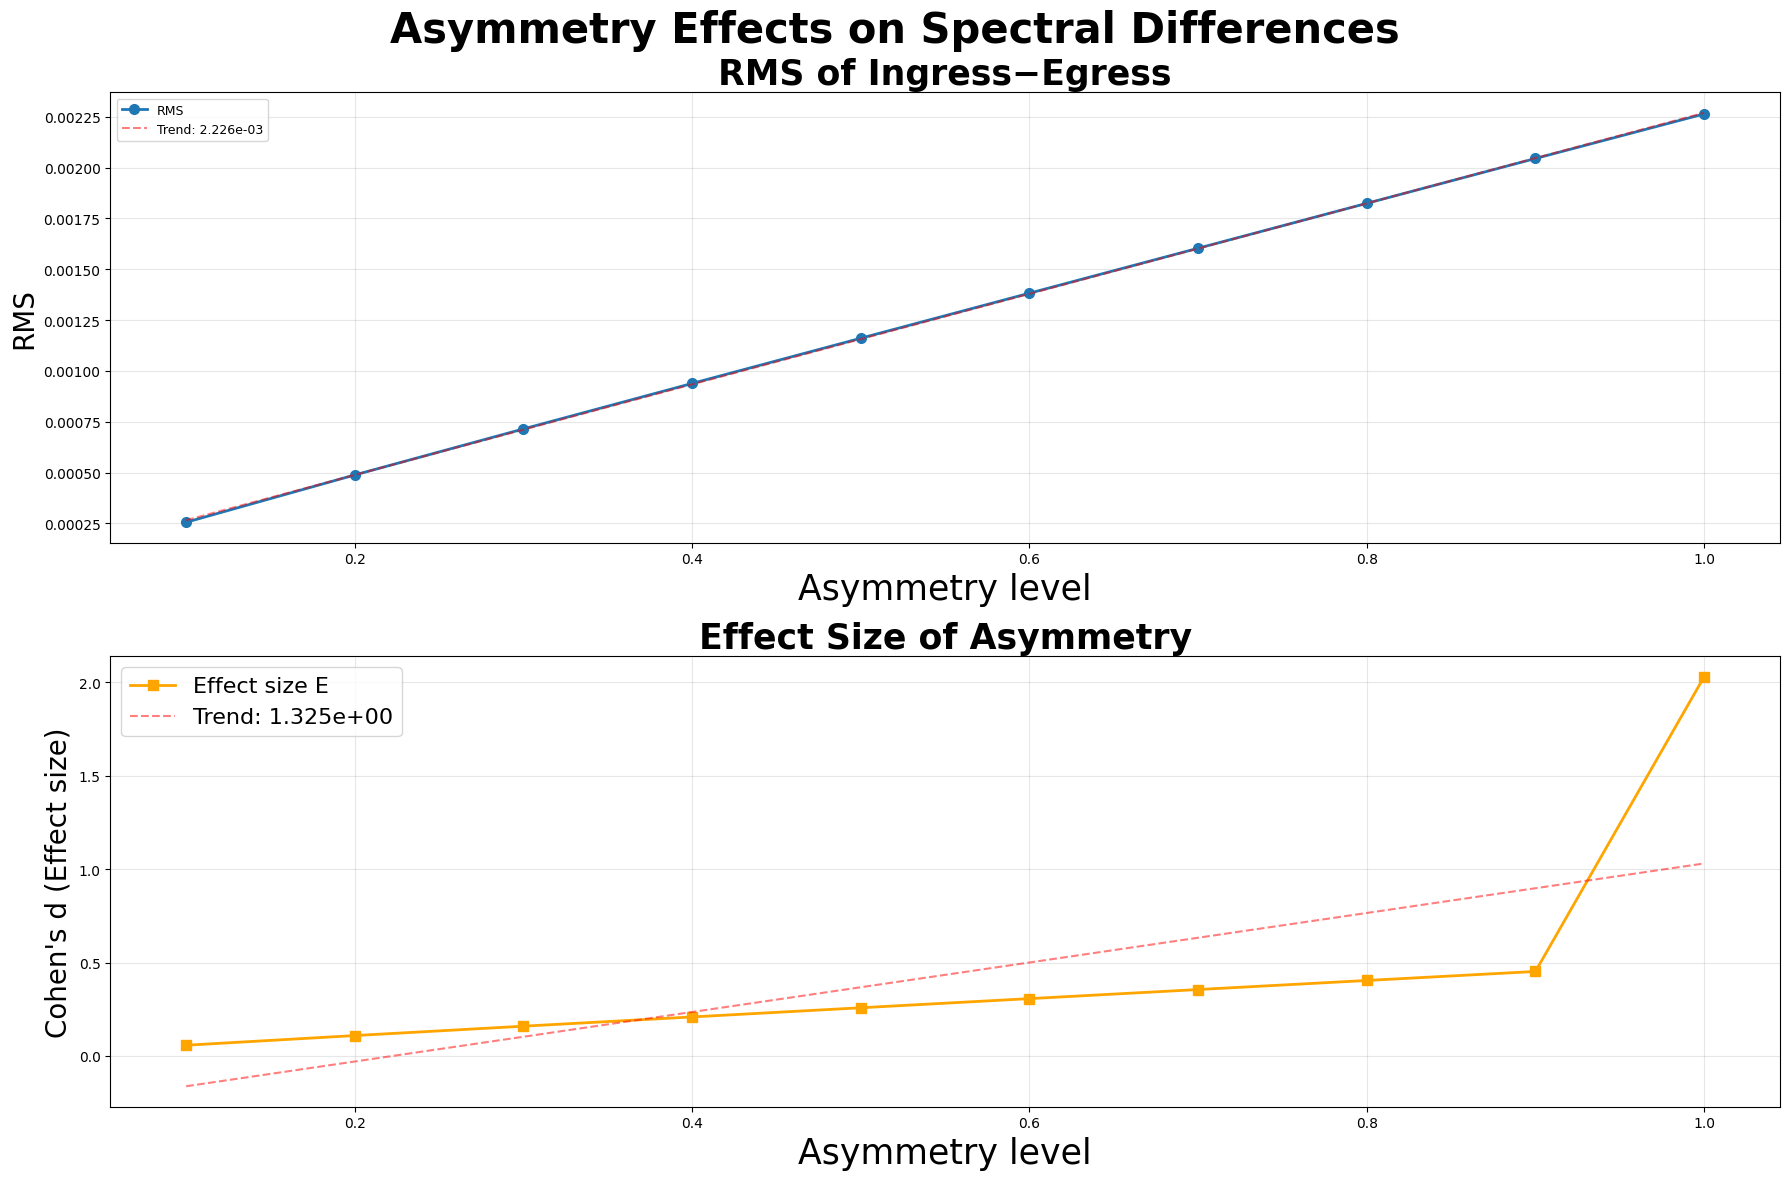

In [21]:
metrics_df = load_global_metrics(folders)
x = np.array([float(f.split("_")[1]) for f in folders])
rms_values = metrics_df['RMS'].to_numpy()
effect_values = metrics_df['E'].to_numpy()
z_rms = np.polyfit(x, rms_values, 1)
z_effect = np.polyfit(x, effect_values, 1)
x_fit = np.linspace(x.min(), x.max(), 200)
rms_fit = np.polyval(z_rms, x_fit)
effect_fit = np.polyval(z_effect, x_fit)
fig, axes = plt.subplots(2, 1, figsize=(18, 12))
ax = axes[0]
ax.plot(x, rms_values, 'o-', label='RMS', linewidth=2, markersize=7)
ax.plot(x_fit, rms_fit, '--', color='red', alpha=0.5, label=f'Trend: {z_rms[0]:.3e}')
ax.set_xlabel("Asymmetry level", fontsize=25)
ax.set_ylabel("RMS", fontsize=20)
ax.set_title("RMS of Ingress−Egress", fontweight='bold', fontsize=25)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9)
ax = axes[1]
ax.plot(x, effect_values, 's-', color='orange', label='Effect size E', linewidth=2, markersize=7)
ax.plot(x_fit, effect_fit, '--', color='red', alpha=0.5, label=f'Trend: {z_effect[0]:.3e}')
ax.set_xlabel("Asymmetry level", fontsize=25)
ax.set_ylabel("Cohen's d (Effect size)", fontsize=20)
ax.set_title("Effect Size of Asymmetry", fontweight='bold', fontsize=25)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=16)
plt.suptitle("Asymmetry Effects on Spectral Differences", fontsize=30, fontweight='bold')
plt.subplots_adjust(top=0.94)
plt.tight_layout()
plt.show()